<a href="https://colab.research.google.com/github/KarlyHdzC/Mineria_de_datos/blob/main/Miner%C3%ADa_de_datos_Sesi%C3%B3n_1_Chunk_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

In [2]:
np.random.seed(42)

# Grupo 1: clientes rápidos (línea)
x_line = np.linspace(0, 10, 50)
y_line = x_line + np.random.normal(0, 0.5, 50)
group_line = np.column_stack((x_line, y_line))

# Grupo 2: paseadores (media luna)
moons, _ = make_moons(n_samples=100, noise=0.05)
group_moons = moons * 5 + [15, 5]

# Grupo 3: electrónicos (cluster compacto)
group_compact = np.random.normal(loc=[5, 15], scale=0.8, size=(40, 2))

# Ruido realista: visitantes no relevantes (poco gasto y tiempo moderado/bajo)
noise = np.column_stack([
    np.random.uniform(0, 12, size=25),  # Tiempo en tienda
    np.random.uniform(0, 3,  size=25)   # Monto gastado (bajo)
])

# Dataset final
X = np.vstack([group_line, group_moons, group_compact, noise])

In [3]:
print(X)

[[ 0.          0.24835708]
 [ 0.20408163  0.13494948]
 [ 0.40816327  0.73200753]
 [ 0.6122449   1.37375983]
 [ 0.81632653  0.69924984]
 [ 1.02040816  0.90333968]
 [ 1.2244898   2.0140962 ]
 [ 1.42857143  1.81228879]
 [ 1.63265306  1.39791587]
 [ 1.83673469  2.10801472]
 [ 2.04081633  1.80910748]
 [ 2.24489796  2.01203308]
 [ 2.44897959  2.56996073]
 [ 2.65306122  1.6964211 ]
 [ 2.85714286  1.99468394]
 [ 3.06122449  2.78008073]
 [ 3.26530612  2.75889056]
 [ 3.46938776  3.62651142]
 [ 3.67346939  3.21945735]
 [ 3.87755102  3.17139917]
 [ 4.08163265  4.81445704]
 [ 4.28571429  4.17282614]
 [ 4.48979592  4.52356002]
 [ 4.69387755  3.98150346]
 [ 4.89795918  4.62576782]
 [ 5.10204082  5.15750211]
 [ 5.30612245  4.73062566]
 [ 5.51020408  5.69805309]
 [ 5.71428571  5.41396637]
 [ 5.91836735  5.77252047]
 [ 6.12244898  5.82159567]
 [ 6.32653061  7.2526697 ]
 [ 6.53061224  6.52386363]
 [ 6.73469388  6.20583841]
 [ 6.93877551  7.35004797]
 [ 7.14285714  6.53243532]
 [ 7.34693878  7.45137057]
 

Desglose de las Filas (215)Es la suma total de las muestras de cada grupo que definiste:Grupo 1 (Línea): 50 puntos (definidos en linspace(0, 10, 50)).Grupo 2 (Lunas): 100 puntos (definidos en n_samples=100).Grupo 3 (Compacto): 40 puntos (definidos en size=(40, 2)).Ruido: 25 puntos (definidos en size=25).

Total: $50 + 100 + 40 + 25 = 215$ filas.

In [4]:
X.shape

(215, 2)

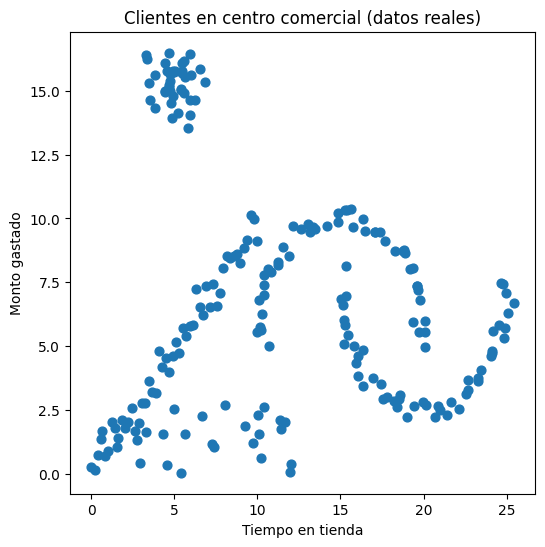

In [5]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], s=40)
plt.title("Clientes en centro comercial (datos reales)")
plt.xlabel("Tiempo en tienda")
plt.ylabel("Monto gastado")
plt.show()

## Aplicación de K-Means

In [6]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
labels_km = kmeans.fit_predict(X)

In [ ]:
print(labels_km)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 2 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 0 1 1 1 1 1 1 2 0 1 1 1 1 1 1 1 2 1 1 1 0 1 1 1 1 1 0 1 1 1 1
 1 1 1 2 1 1 2 0 1 1 2 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 2 1
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [7]:
labels_km.shape

(215,)

In [8]:
print(kmeans.cluster_centers_[:, 0])

[ 6.6965392  18.88629922  5.79118042]


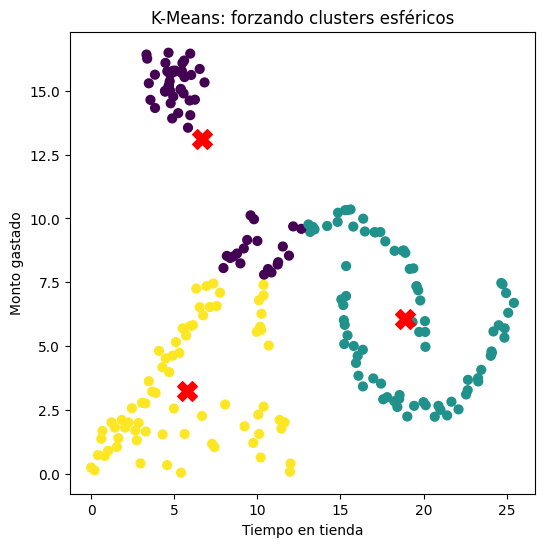

In [9]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=labels_km, cmap="viridis", s=40)
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            c="red", s=200, marker="X")
plt.title("K-Means: forzando clusters esféricos")
plt.xlabel("Tiempo en tienda")
plt.ylabel("Monto gastado")
plt.show()

El Coeficiente de Silueta promedio para K-Means es: 0.52


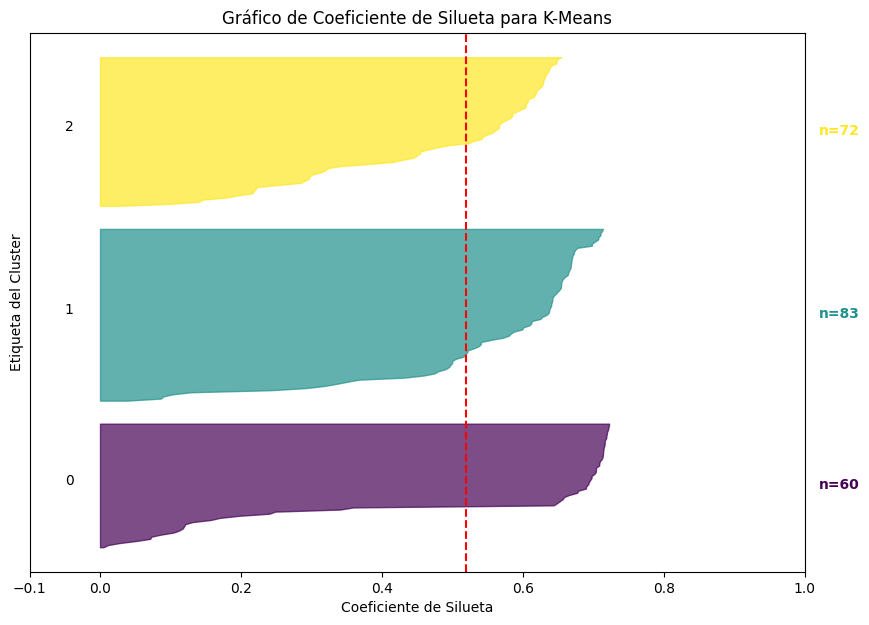

In [10]:
import matplotlib
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm
import numpy as np
import matplotlib.pyplot as plt

silhouette_avg_km = silhouette_score(X, labels_km)
sample_silhouette_values_km = silhouette_samples(X, labels_km)

print(f"El Coeficiente de Silueta promedio para K-Means es: {silhouette_avg_km:.2f}")

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

y_lower = 10

# Correct way to get a discrete colormap from the registry
cmap = matplotlib.colormaps.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, kmeans.n_clusters))

for i in range(kmeans.n_clusters):
    # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
    ith_cluster_silhouette_values = sample_silhouette_values_km[labels_km == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = colors[i]
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )

    # Label the cluster number on the left
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    # Add the sample count on the right side (opposite side)
    ax.text(1.02, y_lower + 0.5 * size_cluster_i, f"n={size_cluster_i}",
            ha='left', va='center', color=color, fontweight='bold')

    y_lower = y_upper + 10

ax.set_title("Gráfico de Coeficiente de Silueta para K-Means")
ax.set_xlabel("Coeficiente de Silueta")
ax.set_ylabel("Etiqueta del Cluster")

ax.axvline(x=silhouette_avg_km, color="red", linestyle="--")

ax.set_yticks([])
ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
plt.show()

El gráfico de silueta para K-Means muestra que:

*   **El Coeficiente de Silueta promedio es relativamente bajo (~0.50)**, lo que indica que, en general, los puntos no están tan bien ajustados a sus clusters.
*   **Algunos clusters tienen una gran cantidad de puntos con coeficientes de silueta por debajo del promedio** (la línea roja punteada) e incluso con valores negativos. Esto es particularmente notorio en el Cluster 0 y 2.
*   **La forma de los 'clusters' en el gráfico de silueta es muy irregular**, lo que sugiere que K-Means ha intentado forzar a los datos en formas esféricas, incluso cuando la geometría subyacente de los datos (como las 'lunas' y la 'línea') no es esférica.

Esto confirma que K-Means, al basarse en la distancia euclidiana y asumir clusters convexos y de forma esférica, tiene dificultades para identificar correctamente las estructuras de datos complejas presentes en este conjunto de datos. Los puntos que están en las 'curvas' de las lunas o a lo largo de la línea recta son los que probablemente tienen puntuaciones de silueta más bajas, ya que K-Means los agrupa con el centroide más cercano en lugar de con su estructura de densidad real.

## DBSCAN

In [14]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.2, min_samples=5)
labels_db = dbscan.fit_predict(X)

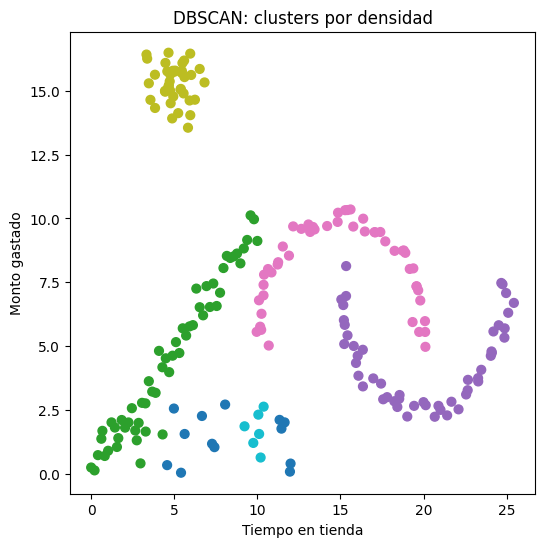

In [15]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=labels_db, cmap="tab10", s=40)
plt.title("DBSCAN: clusters por densidad")
plt.xlabel("Tiempo en tienda")
plt.ylabel("Monto gastado")
plt.show()

## Traducción de los clusters

In [16]:
import pandas as pd

df_clusters = pd.DataFrame(X, columns=["Tiempo_en_tienda", "Monto_gastado"])
df_clusters["Cluster"] = labels_db

df_clusters.head()

,Tiempo_en_tienda,Monto_gastado,Cluster
0,0.000000,0.248357,0
1,0.204082,0.134949,0
2,0.408163,0.732008,0
3,0.612245,1.373760,0
4,0.816327,0.699250,0


In [17]:
df_clusters.groupby("Cluster").mean()

,Tiempo_en_tienda,Monto_gastado
Cluster,,
-1,8.336740,1.391218
0,4.741378,4.500303
1,20.039894,4.402803
2,15.005795,8.188560
3,5.010512,15.298358
4,9.953412,1.703018


In [18]:
cluster_translation = {
    0: "Clientes rápidos: entran, compran algo puntual y se van (café / conveniencia)",
    1: "Paseadores: recorren la tienda, bajo gasto, alto tiempo (exploradores)",
    2: "Compradores intensivos: alto gasto, poco tiempo (electrónica / compras focalizadas)",
    -1: "Ruido: visitantes no relevantes (baño, información, acompañantes)"
}

In [19]:
df_clusters["Segmento_negocio"] = df_clusters["Cluster"].map(cluster_translation)

df_clusters.head(10)

,Tiempo_en_tienda,Monto_gastado,Cluster,Segmento_negocio
0,0.000000,0.248357,0,"Clientes rápidos: entran, compran algo puntual..."
1,0.204082,0.134949,0,"Clientes rápidos: entran, compran algo puntual..."
2,0.408163,0.732008,0,"Clientes rápidos: entran, compran algo puntual..."
3,0.612245,1.373760,0,"Clientes rápidos: entran, compran algo puntual..."
4,0.816327,0.699250,0,"Clientes rápidos: entran, compran algo puntual..."
5,1.020408,0.903340,0,"Clientes rápidos: entran, compran algo puntual..."
6,1.224490,2.014096,0,"Clientes rápidos: entran, compran algo puntual..."
7,1.428571,1.812289,0,"Clientes rápidos: entran, compran algo puntual..."
8,1.632653,1.397916,0,"Clientes rápidos: entran, compran algo puntual..."
9,1.836735,2.108015,0,"Clientes rápidos: entran, compran algo puntual..."


In [20]:
df_clusters.groupby("Segmento_negocio")[["Tiempo_en_tienda", "Monto_gastado"]].mean()

,Tiempo_en_tienda,Monto_gastado
Segmento_negocio,,
"Clientes rápidos: entran, compran algo puntual y se van (café / conveniencia)",4.741378,4.500303
"Compradores intensivos: alto gasto, poco tiempo (electrónica / compras focalizadas)",15.005795,8.188560
"Paseadores: recorren la tienda, bajo gasto, alto tiempo (exploradores)",20.039894,4.402803
"Ruido: visitantes no relevantes (baño, información, acompañantes)",8.336740,1.391218
